# L'objectif est de creer une IA en machine learning de Clustering.
**Je cherche à regrouper les pays selon leur niveau de développement** <br>
Le clustering permettra d’identifier des profils de pays (développés, en développement, etc.) sans utiliser de variable cible.
* Cluster 1 : pays riches
* Cluster 2 : pays en développement
* Cluster 3 : pays pauvres

## DataSet :
1. Ce dataset contient des informations socio-économiques sur **167 pays en 2010**.
2. 1 feature texte (country)
3. 9 feature numériques décrivant différents aspects du développement d’un pays :
* child_mort : nombre de décès d’enfants de moins de 5 ans pour 1000 naissances
* exports : exportations (% du PIB)
* health : dépenses de santé (% du PIB)
* imports : importations (% du PIB)
* income : revenu moyen par habitant
* inflation : taux de croissance annuel
* life_expec : espérance de vie
* total_fer : nombre moyen d’enfants par femme
* gdpp : PIB par habitant

### liens du Data Set :
https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data/data

## Observation :

Se baser sur **une seule variable comme le GDP peut être trompeur**, car le développement d’un pays dépend de plusieurs facteurs comme la santé, l’éducation et les conditions de vie.
Le clustering permet de prendre en compte plusieurs dimensions simultanément.

## Voici une visualisation du data set:

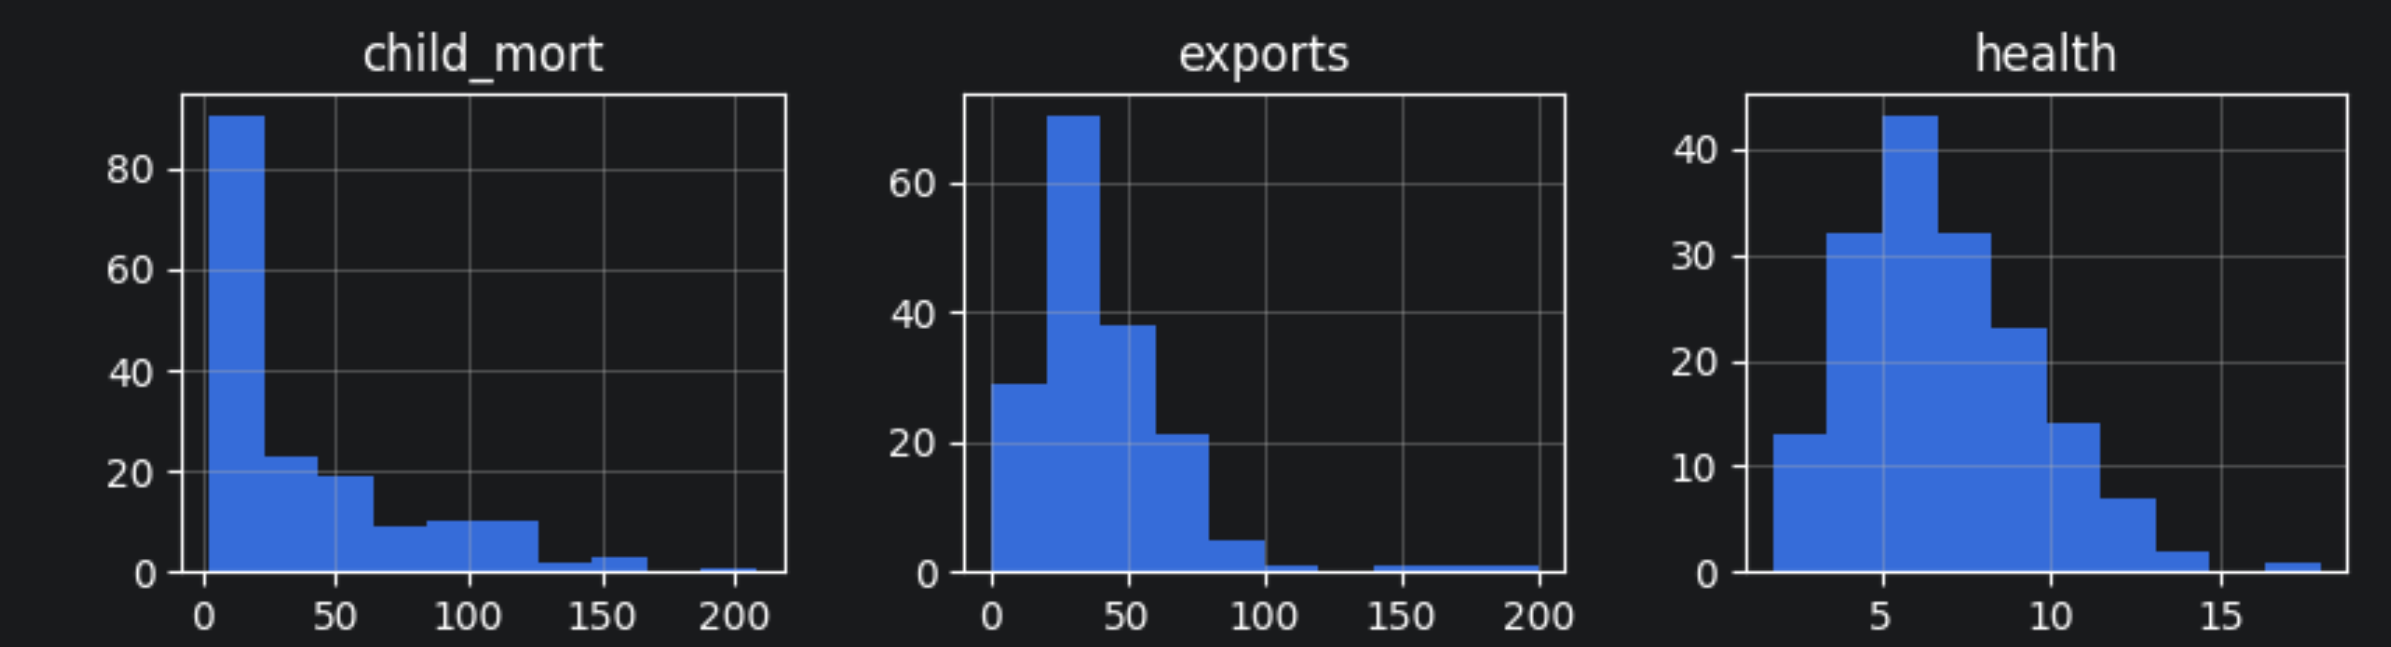
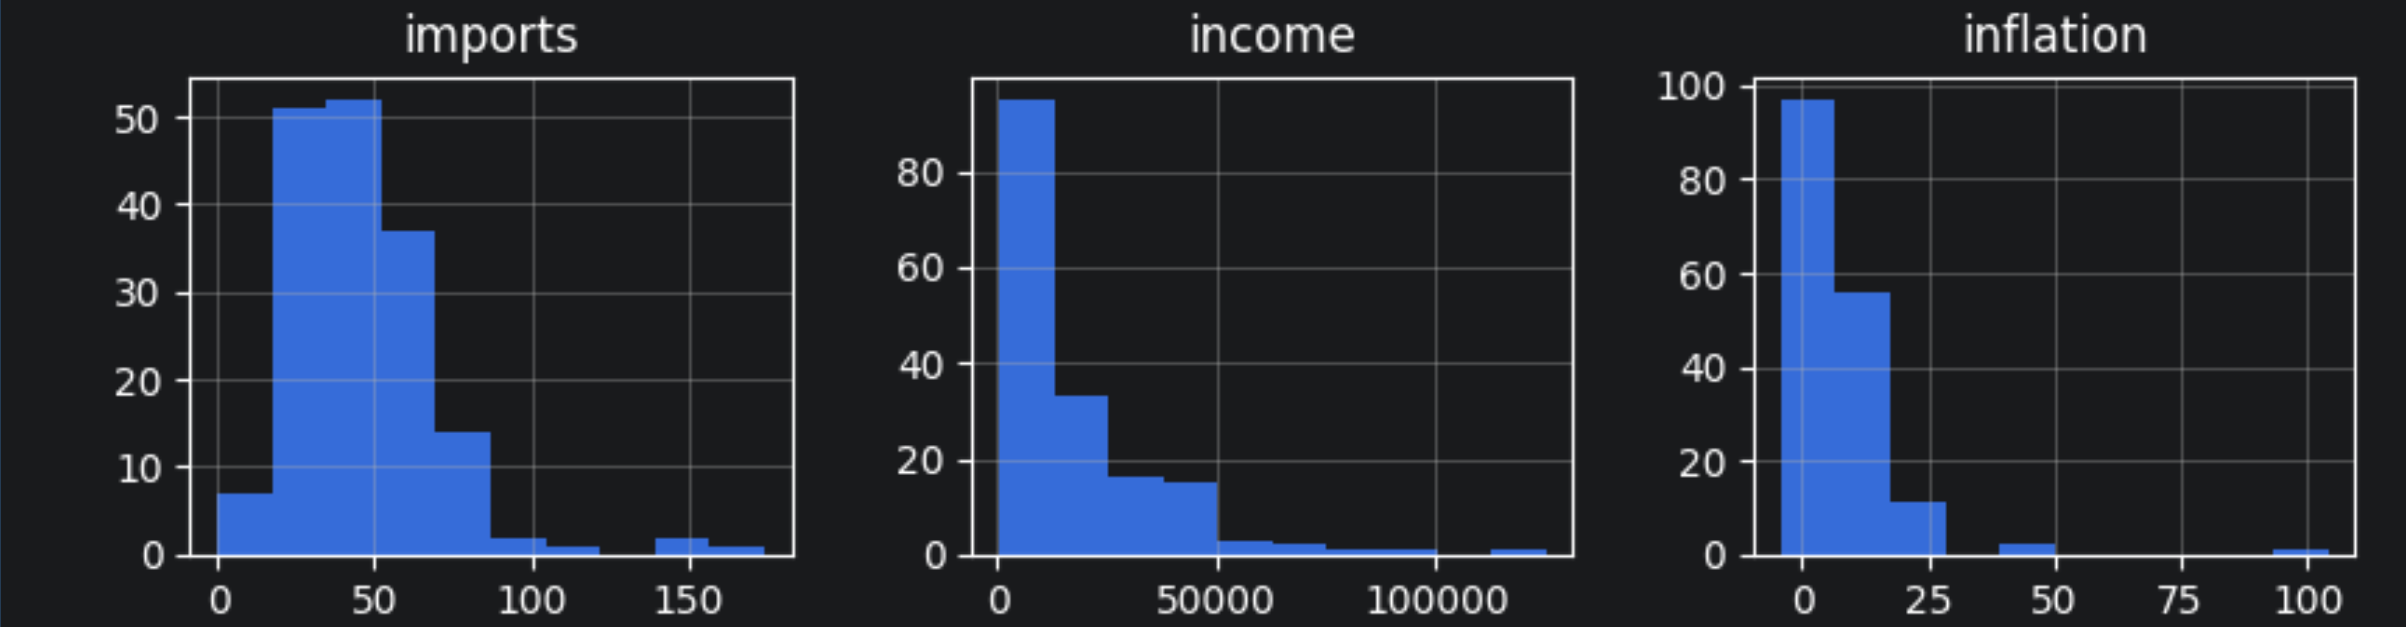
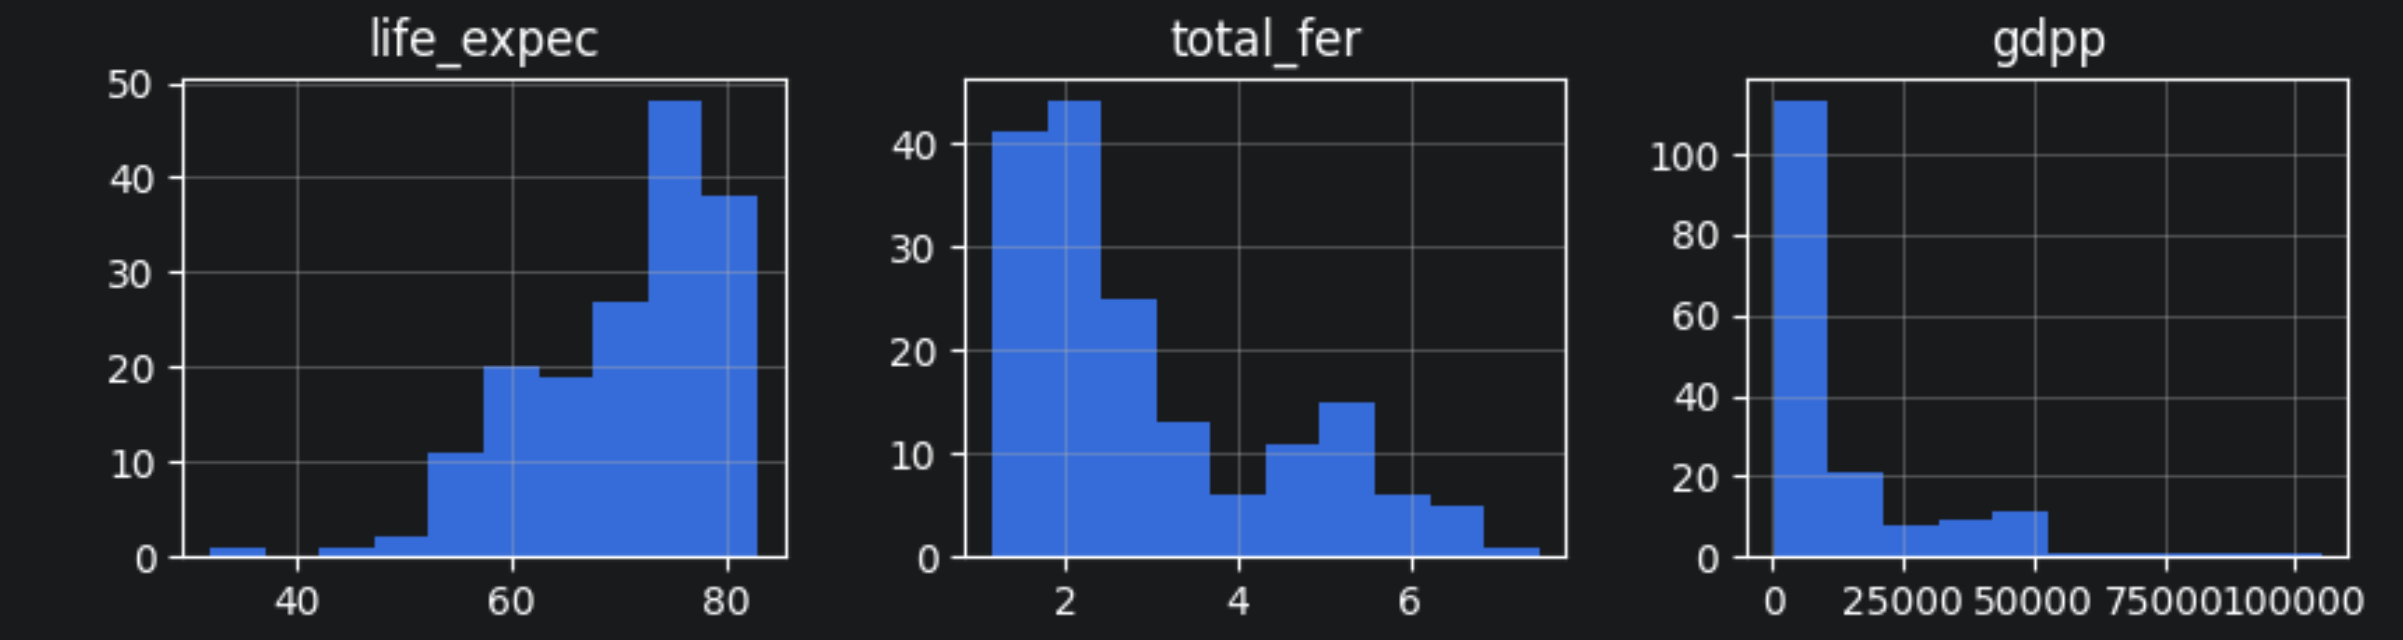


## Algotithme et Model
1. KMeans :
* on crée k groupes autour de centres
2. Agglomerative Clustering (HIÉRARCHIQUE)
* construit les clusters en fusionnant progressivement les points selon une distance donnée
3. DBSCAN
* regroupe les points en fonction de leur densité et permet d’identifier des valeurs aberrantes.
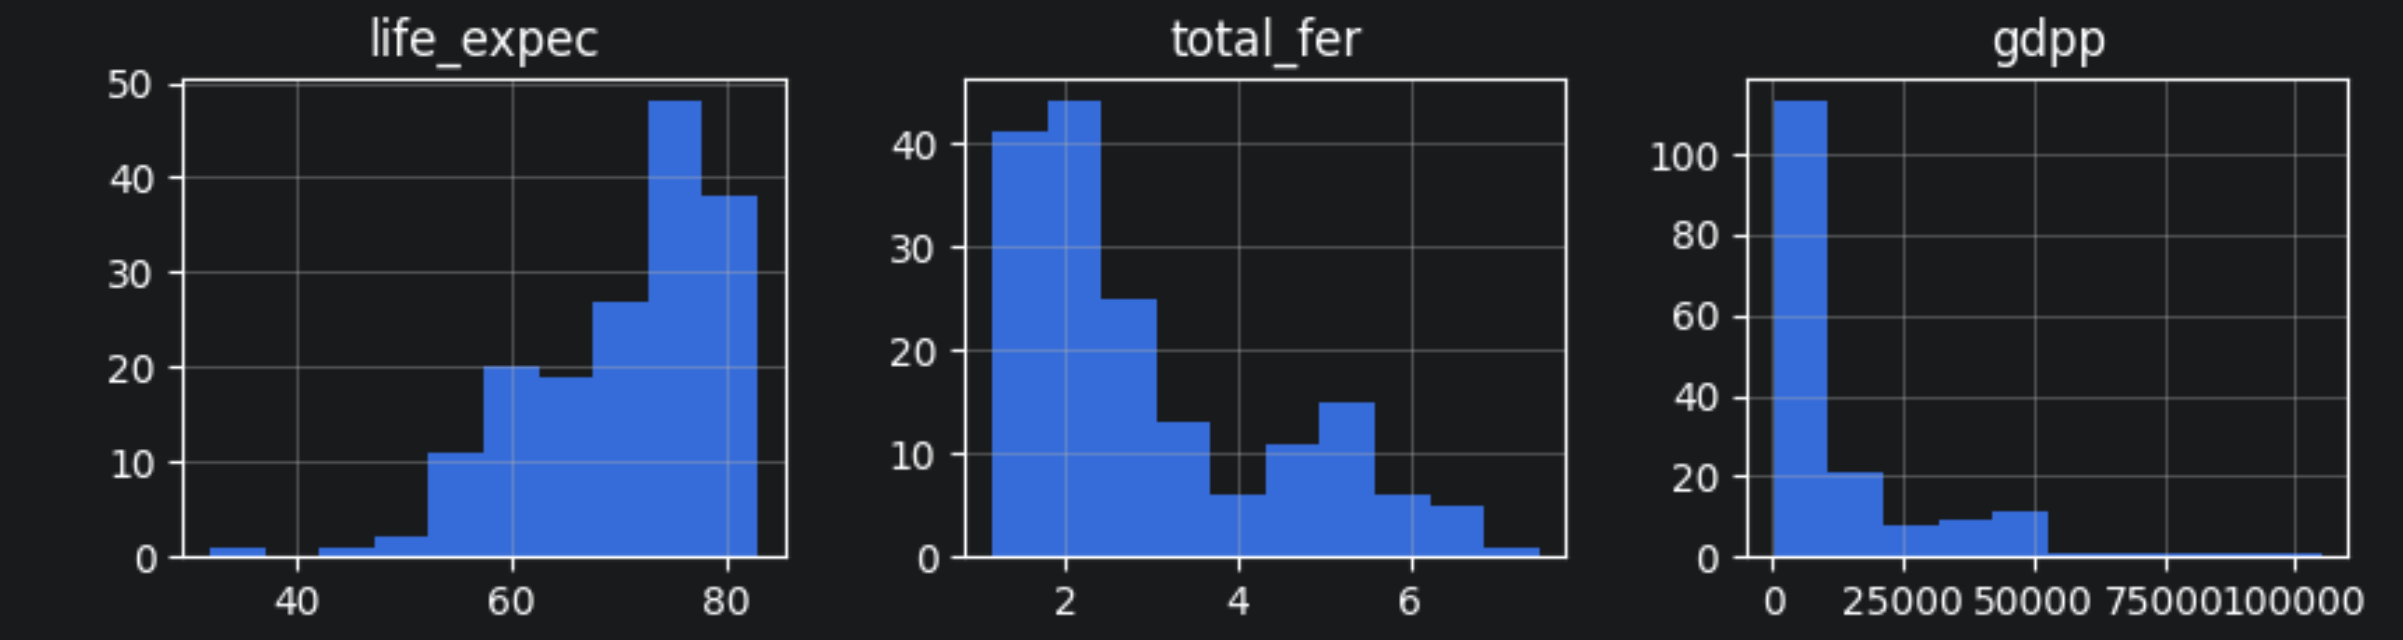

In [37]:
import pandas as pd

df = pd.read_csv("Country Data/Country-data.csv", sep=";")
print(df.columns)
print(df.head())
df.describe()
df.info()

#df.hist(figsize=(10,8))

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  

Normalisation de la Donnée
* Une variable dont les valeurs vont de 0 à 1 000 000 (ex: le Revenu) écrasera totalement une variable qui va de 0 à 10 (ex: le taux de chômage).

In [38]:
from sklearn.preprocessing import StandardScaler

df = df.drop(columns=["country"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

**méthode du coude (ou Elbow Method)** : apprentissage non supervisé pour déterminer le nombre optimal de clusters ($k$) à **utiliser avec l'algorithme K-Means.**

2 0.2662961111870726
3 0.285600988953231
4 0.2880471307804802
5 0.30088229124112015
6 0.23565028812238528
7 0.2479313491087983
8 0.20198237114728412
9 0.19230727869997855
10 0.19624516158796698


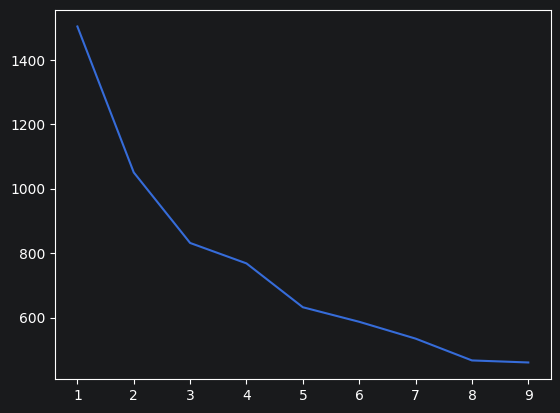

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)

for k in [2,3,4,5, 6, 7, 8, 9, 10]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(k, score)

# Model 1 : kmeans

In [32]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

# Model 2 : Agglomerative Clustering

In [22]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=5)
clusters_agglo = agglo.fit_predict(X_scaled)

df["cluster_agglo"] = clusters_agglo

# Model 3 : DBSCAN

In [39]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=5)
clusters_db = dbscan.fit_predict(X_scaled)

df["cluster_dbscan"] = clusters_db

Visualisation : **PCA**

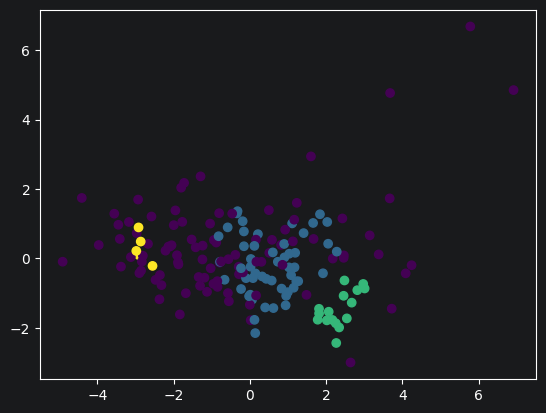

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
#plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_agglo)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_db)

Évaluation:
* Proche de 1 => Les clusters sont denses et très bien séparés.
* Proche de 0 => Les clusters se chevauchent ou la distance entre eux est très faible.
* Négatif => Des points ont probablement été affectés au mauvais cluster.

In [41]:
from sklearn.metrics import silhouette_score

#silhouette_score(X_scaled, clusters)
#silhouette_score(X_scaled, clusters_agglo)
silhouette_score(X_scaled, clusters_db)

-0.024818901891032592

moyenne des donne des cluster

In [42]:
#df.groupby("cluster").mean()
#df.groupby("cluster_agglo").mean()
df.groupby("cluster_dbscan").mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_dbscan,,,,,,,,,
-1,53.218085,43.187223,6.266596,48.023041,16667.819149,11.038447,67.552128,3.517660,11462.287234
0,17.036538,41.371154,6.814808,50.117308,13278.076923,3.607385,74.263462,2.050192,8157.038462
1,4.125000,33.393750,10.219375,32.775000,37312.500000,1.371125,81.006250,1.720000,41237.500000
2,87.340000,24.000000,6.256000,37.200000,1785.600000,10.486000,55.020000,5.504000,718.600000


calcule du meilleur Eps pour DBSCAN

In [36]:
import numpy as np

for eps in [0.5, 1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_scaled)
    print(eps, np.unique(db.labels_))

0.5 [-1]
1.0 [-1  0  1  2]
1.5 [-1  0]
2.0 [-1  0]


# Remarque :

Normalisation de la Donnée :
* suppression collone contry car pas de valeur numerique pour Kmeans

### Interpretation des resultat:
1. PCA :
* technique de réduction de dimension pour passer d'un tableau a 9 dimention actuellement a un tableau en 2 dimmention
2. silhouette_score(X_scaled, clusters) :
* Proche de 1 => Les clusters sont denses et très bien séparés.
* Proche de 0 => Les clusters se chevauchent ou la distance entre eux est très faible.
* Négatif => Des points ont probablement été affectés au mauvais cluster.
3. df.groupby("cluster").mean()
* la moyenne de chaque variable pour chaque groupe d'individus
* profil type de chaque cluster

# Resultat des tests :

### Test 1 : Model KMeans avec 9 cluster et un random_state de 42 : KMeans(n_clusters=9, random_state=42)

![image.png](attachment:4ad3377f-844b-4726-afc7-a4661a2cd8c3.png)

silhouette_score = 0.19230727869997855 <br>

df.groupby("cluster").mean()

![image.png](attachment:c01d6883-9d98-413b-98d7-81d79dd94777.png)

Conclusion :
* les point dans les cluster sont completement melanger
* le silhoute score en proche de 0 se qui confirme que les cluster son mal place.

### Test 2: mise en place de la méthode du coude (ou Elbow Method)

![image.png](attachment:906a0419-dc5a-45fe-b0fa-f26d8aa67419.png)

Conclusion : Le coude apparaît autour de k = 3, ce qui suggère que 3 clusters est un bon compromis. de plus ceci simplifie l'interpretation.

### Test 3 : model 1 Kmeans avec 3 cluster

![image.png](attachment:8f8788a4-5586-4589-a826-70612f553738.png)

silhouette_score = 0.285600988953231 <br>

df.groupby("cluster").mean()

![image.png](attachment:88c61578-5ce3-4f6d-9bf7-52e229269370.png)


conclusion :
* avec 3 cluster les resultat obtenue sont bien plus probant
* augmentation du silhouette_score mais avec un score faible ce qui indique une séparation modérée des cluster
* les cluster sont beaucoup plus clair avec aucun point se trouvant dans un nuage autre que le siens <br>

les cluster :
1. un groupe de pays développés avec un revenu élevé et une faible mortalité,
2. un groupe de pays en développement avec des indicateurs intermédiaires,
3. un groupe de pays pauvres caractérisé par une forte mortalité infantile et un faible revenu.


### Test 4 : Model 2 Agglomerative Clustering avec 3 cluster

![image.png](attachment:28a03049-8671-491e-98be-a1e22dd5f50d.png)

silhouette_score = 0.24563001303300652 <br>

![image.png](attachment:a312dc42-3f17-4b73-bf10-939aefda520b.png)

conlcusion :
* la visualisation montre des cluster moins bien repartie qu'avec le model Kmeans, avec des point se trouvant proche de nuage d'autre cluster.
* le silhouette_scrore confirme la visualisation avec un score plus petit qu'au test precedant
* Agglomerative clustering produit des clusters similaires à KMeans mais avec une séparation légèrement moins bonne.

### Test 5 : Model 3 DBSCAN

![image.png](attachment:6328c4c9-cef4-41da-9cc4-adfe87496fca.png)

silhouette_score = 0.28829596251907025

![image.png](attachment:61ce8a25-370a-4a3e-864d-4494d3f22729.png)

Conclusion :
* un silhouette_score supperieur a Kmeans et au autre model
* beaucoup de outlier (-1) et seulement 2 cluster
* ne permet pas de segmenter clairement les pays en plusieurs groupes
* limite son interprétation

### Test 6 : Model 3 DBSCAN determiner la meilleur variable de eps

0.5 [-1] <br>
1.0 [-1  0  1  2] <br>
1.5 [-1  0] <br>
2.0 [-1  0] <br>

conclusion :
* le seul cas interesant est 1.0 car cet le seul a repere plusieur cluster

### Test 7 : Model 3 DBSCAN  eps = 1.0

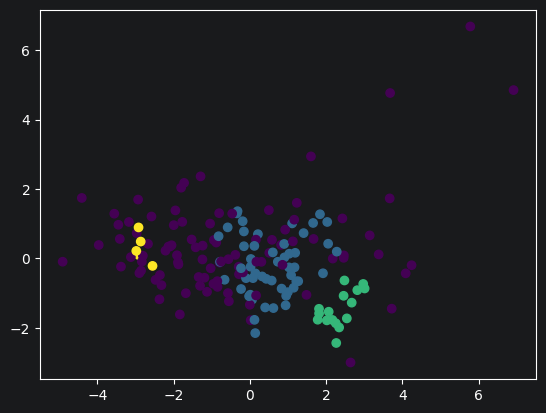

silhouette_score = -0.024818901891032592

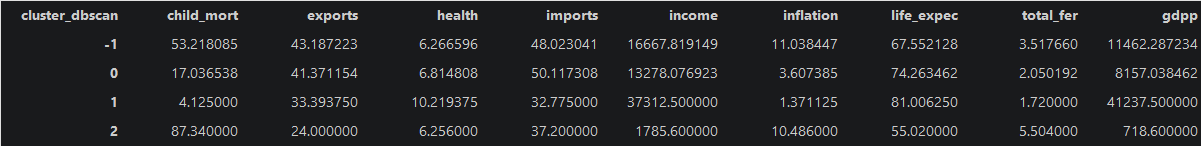

conclusion :
* Cependant, une grande partie des données est classée comme bruit (cluster -1), ce qui montre que le modèle ne parvient pas à structurer correctement l’ensemble du dataset.


### Test 8 : Model 1 KMeans recherche d'un K avec un silhouette_score le plus elever.
2 0.2662961111870726 <br>
3 0.285600988953231 <br>
4 0.2880471307804802 <br>
5 0.30088229124112015 <br>
6 0.23565028812238528 <br>
7 0.2479313491087983 <br>
8 0.20198237114728412 <br>
9 0.19230727869997855 <br>
10 0.19624516158796698 <br>

conclusion :
* il semble que le nombre obtimal de cluster soit 5 pour obtenir le silhouette_score le plus elever.
* attention 5 cluster fait une interpretation plus complexe.

### Test 9 :  Model 1 KMeans avec K = 5

![image.png](attachment:3ee7901b-71bd-4821-83e4-017163c10ed7.png)

silhouette_score = 0.30088229124112015

![image.png](attachment:99f42b9c-9e18-487e-9971-63b65fcf7518.png)

Conclusion :
* silhouette_score a un peut augmenter comme prevue.
* les point sont meiux repartie, avec cependant un peut plus de chevauchement qu'avec K = 3
* Cluster :
0. Pays intermédiaires / Pays en développement <br>
income ≈ 12k <br>
life_expec ≈ 72 <br>
Amérique du Sud, Europe de l’Est… <br>

1. Pays riches classiques / Pays développés <br>
income ≈ 44k <br>
life_expec ≈ 80 <br>
child_mort ≈ 5 <br>
Europe, USA, etc. <br>

2. Pays pauvres / Pays en difficulté <br>
income ≈ 3500 <br>
life_expec ≈ 59 <br>
child_mort ≈ 94 <br>
Afrique subsaharienne, etc. <br>

3.  Cas extrêmes <br>
child_mort ≈ 130 (!!) <br>
inflation ≈ 104 (!!) <br>
income ≈ 5150 <br>
Pays en crise / instables <br>

4. Ultra riches / outliers économiques ( les point en haut a droite) <br>
income ≈ 64k <br>
exports ≈ 176 (!!) <br>
imports ≈ 156 (!!) <br>
gdpp ≈ 57k <br>
Luxembourg, Singapour, Qatar… <br>


# Conclusion :
* Je choisis KMeans, car il permet d’obtenir trois clusters clairement interprétables correspondant aux niveaux de développement des pays.
* DBSCAN obtient un score silhouette légèrement supérieur, il ne fournit pas une segmentation exploitable
* AgglomerativeClustering obtien malheuresement de mon bon score que KMeans en etant tres proche .
* Bien que k=3 offre une segmentation simple des pays en trois niveaux de développement, le choix de k=5 permet une analyse plus fine en distinguant des groupes spécifiques comme les pays très riches ou les pays en situation de crise. Cette segmentation apporte une meilleure compréhension des données.